In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:

df = pd.read_csv("covid_19_data.csv")
df

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
306424,306425,05/29/2021,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0
306425,306426,05/29/2021,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0
306426,306427,05/29/2021,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0
306427,306428,05/29/2021,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0


In [43]:
print(df[["Confirmed", "Deaths", "Recovered"]].describe())

          Confirmed         Deaths     Recovered
count  3.064290e+05  306429.000000  3.064290e+05
mean   8.567091e+04    2036.403268  5.042029e+04
std    2.775516e+05    6410.938048  2.015124e+05
min   -3.028440e+05    -178.000000 -8.544050e+05
25%    1.042000e+03      13.000000  1.100000e+01
50%    1.037500e+04     192.000000  1.751000e+03
75%    5.075200e+04    1322.000000  2.027000e+04
max    5.863138e+06  112385.000000  6.399531e+06


In [44]:
Q1 = df["Confirmed"].quantile(0.25)
Q3 = df["Confirmed"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

out = df[
    (df["Confirmed"] < lower) |
    (df["Confirmed"] > upper)
]["Confirmed"]

In [45]:
quartiles = df[["Confirmed", "Deaths", "Recovered"]].quantile([0.25, 0.50, 0.75])
quartiles.index = ["Q1 (25%)", "Q2 (50%)", "Q3 (75%)"]
print(quartiles)

          Confirmed  Deaths  Recovered
Q1 (25%)     1042.0    13.0       11.0
Q2 (50%)    10375.0   192.0     1751.0
Q3 (75%)    50752.0  1322.0    20270.0


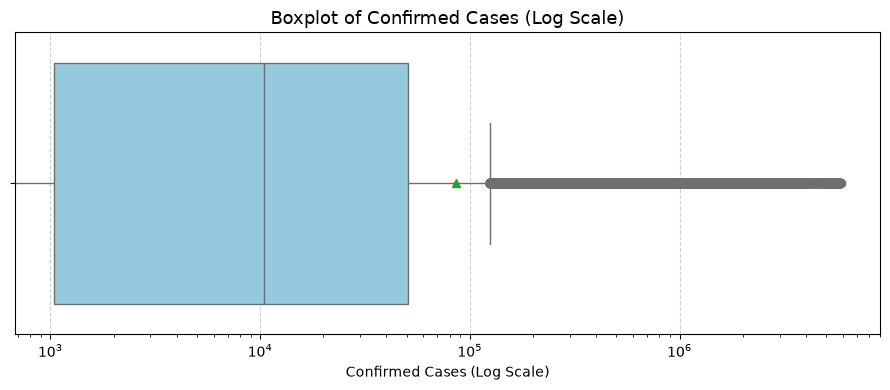

In [46]:
plt.figure(figsize=(9, 4))
sns.boxplot(x=df["Confirmed"], color="skyblue", showmeans=True)
plt.xscale("log")
plt.title("Boxplot of Confirmed Cases (Log Scale)", fontsize=13)
plt.xlabel("Confirmed Cases (Log Scale)")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

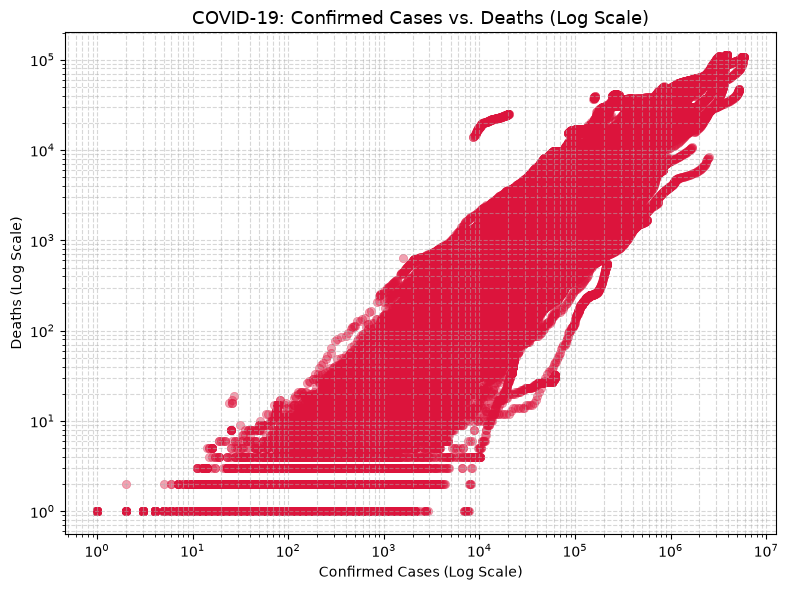

In [ ]:
plot_data = df[(df["Confirmed"] > 0) & (df["Deaths"] > 0)]
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_data,
    x="Confirmed",
    y="Deaths",
    alpha=0.4,       # Transparency prevents dense clusters from blinding the plot
    color="crimson",
    edgecolor=None
)
# Apply log scale to both axes
plt.xscale("log")
plt.yscale("log")
plt.title("COVID-19: Confirmed Cases vs. Deaths (Log Scale)", fontsize=13)
plt.xlabel("Confirmed Cases (Log Scale)")
plt.ylabel("Deaths (Log Scale)")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()